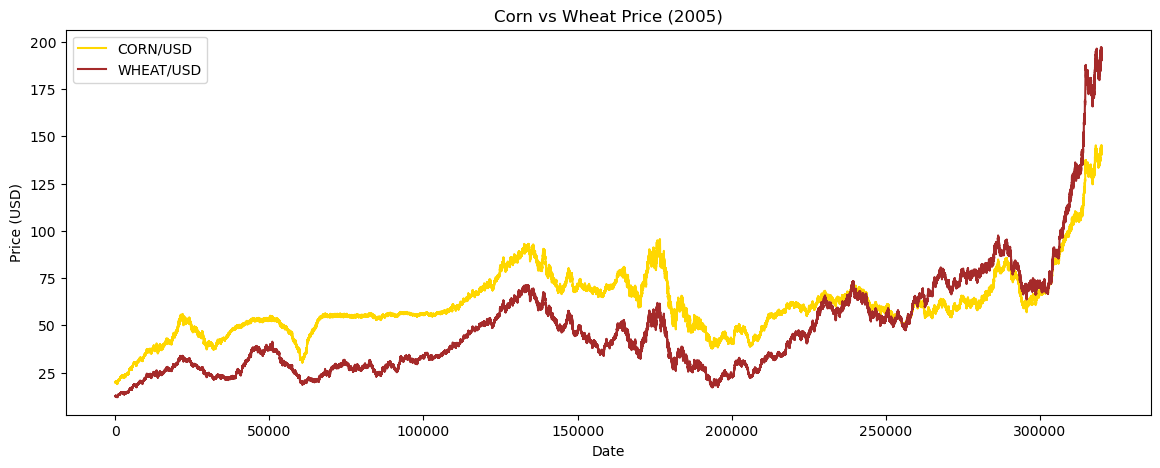

In [23]:
corn_path = 'dataset/CORN_USD_2005_2020.csv'
wheat_path = 'dataset/WHEAT_USD_2005_2020.csv'
CSV_C = 'data-scripts/data.csv'
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

df_a = pd.read_csv(CSV_C)[['s1']].dropna()
df_b = pd.read_csv(CSV_C)[['s2']].dropna()
df_a = df_a.rename(columns={"s1": "close"})
df_b = df_b.rename(columns={"s2": "close"})
df_a = df_a[int(0*len(df_a)):int(len(df_a))]
df_b = df_b[int(0*len(df_b)):int(len(df_b))]
corn = df_a
wheat = df_b
# corn = pd.read_csv(corn_path, parse_dates=['time'], index_col='time')
# wheat = pd.read_csv(wheat_path, parse_dates=['time'], index_col='time')

plt.figure(figsize=(14, 5))
plt.plot(corn['close'], label='CORN/USD', color='gold')
plt.plot(wheat['close'], label='WHEAT/USD', color='brown')
plt.title('Corn vs Wheat Price (2005)')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.show()

In [24]:
# diff = corn.index[-1] - corn.index[0]
# years = diff.total_seconds() / (365.25 * 24 * 3600)
# print(years)

In [25]:
train_size = int(0.8*len(corn['close']))
train_A = corn['close'][:train_size]
train_B = wheat['close'][:train_size]
test_A = corn['close'][train_size:]
test_B = wheat['close'][train_size:]

In [26]:
def estimate_beta_OU(A, B):
    a_log = np.log(A)
    b_log = np.log(B).values.reshape(-1, 1)
    
    model = LinearRegression().fit(b_log, a_log)

    return model.coef_[0]

beta = estimate_beta_OU(train_A, train_B)

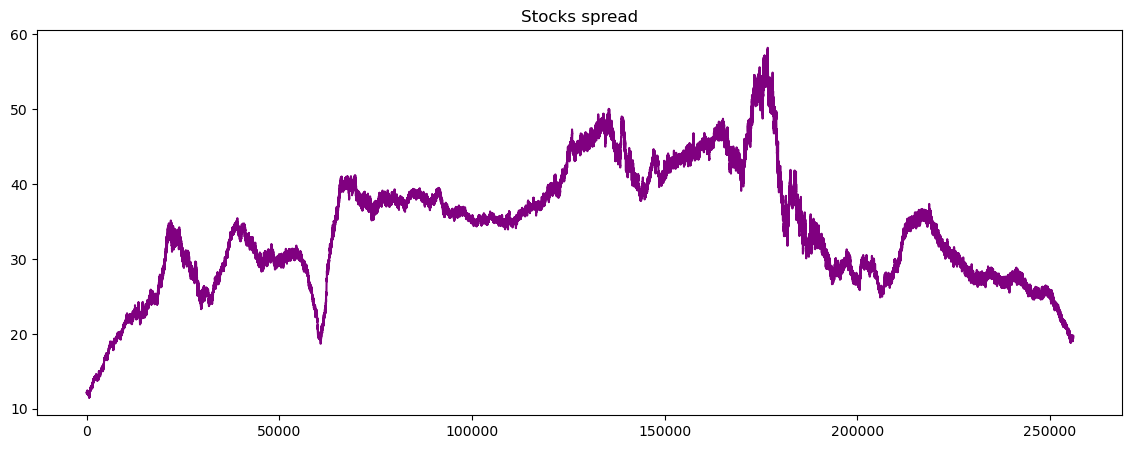

In [27]:
train_spread = train_A-beta*train_B
test_spread = test_A-beta*test_B
plt.figure(figsize=(14, 5))
plt.plot(train_spread, label='spread', color='purple')
plt.title("Stocks spread")
plt.show()

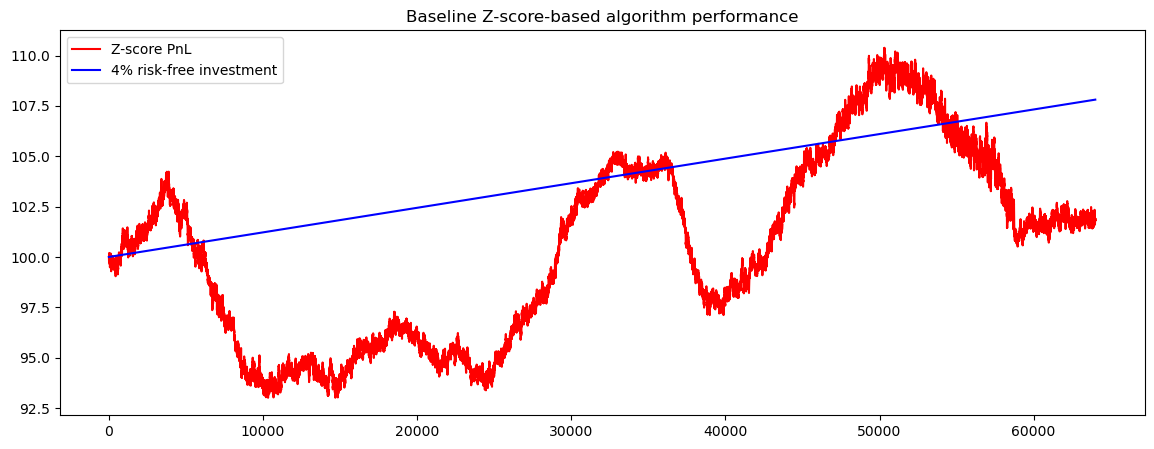

In [ ]:
def print_pnl(spread, stock_A, stock_B):
    z = 1.5
    money = 100
    mean = np.mean(train_spread)
    sd = np.std(train_spread)
    pnl = []
    position = 0
    for i in range(len(spread)):
        curz = (spread.iloc[i]-mean)/sd
        if position < 0 and -z < curz <= 0:
            money += position * spread.iloc[i]
            position=0
        elif position > 0 and 0 <= curz < z:
            money += position*spread.iloc[i]
            position=0
        elif curz>=z:
            money += position*spread.iloc[i]
            maxpos = money/(np.abs(stock_A.iloc[i])+np.abs(beta*stock_B.iloc[i]))
            position=-maxpos
            money-=position*spread.iloc[i]
        elif curz<=-z:
            money+=position*spread.iloc[i]
            maxpos = money/(np.abs(stock_A.iloc[i])+np.abs(beta*stock_B.iloc[i]))
            position=maxpos
            money-=position*spread.iloc[i]
        pnl.append(position*spread.iloc[i]+money)

    plt.figure(figsize=(14, 5))
    plt.plot(pnl, label='Z-score PnL', color='red')
    plt.plot(np.linspace(100, 100*1.04 ** (0.2*3500/365), len(pnl)), label="4% risk-free investment", color='blue')
    plt.legend()
    plt.title("Baseline Z-score-based algorithm performance")
    plt.show()
    return pnl

pnl = print_pnl(test_spread, test_A, test_B)

In [29]:
# Simpler version
df = pd.DataFrame(pnl, columns=['values'])
returns = df['values'].pct_change().dropna()
sharpe_ratio = (returns.mean() / returns.std()) * np.sqrt(33371)

print(f"Annualized Sharpe Ratio: {sharpe_ratio:.4f}")

Annualized Sharpe Ratio: 0.1375
